In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Abstract

Overweight and obesity present severe public health challenges, increasing the risk of cardiovascular disease, type 2 diabetes, musculoskeletal disorders, and premature mortality (Obesity: Health Consequences of Being Overweight, n.d.). This study analyzes datasets from the **Global Burden of Disease (GBD) 2021** study to determine whether obesity rates among the 5-24 age group are influenced by demographic and geographic factors. The analysis indicates a steady annual increase in youth obesity prevalence, with significant differences observed across age groups, genders, and geographic regions. Specially, the highest rates were found among young adults aged 20-24 and females. These findings demonstrate that obesity rates are indeed influenced by demographic and geographic factors, highlighting the need for tailored, geographically targeted public health policies.



Load dataset into Pandas dataframe

In [2]:
df = pd.read_csv('OB_ONLY.CSV')

# 2. Dataset Description

The dataset used in this project was obtained from the **Global Burden of Disease (GBD) Study 2021**, specifically the **Child and Adolescent Overweight and Obesity Estimates and Forecasts** dataset, coordinated by the **Institute for Health Metrics and Evaluation (IHME)**. It contains estimates of the annual prevalence of overweight and obesity among children and adolescents across multiple countries and territories.

The dataset covers historical estimates from 1990 to 2021 and forecasted estimates from 2022 to 2050. It includes annual estimates of overweight and obesity prevalence among children and adolescents across multiple countries and territories.

### 2.1 How the Data Was Collected

The estimates were developed using 1,321 unique sources containing measurements of height and weight collected from 180 countries and territories. These sources included measured and self-reported height and weight data obtained from survey microdata, national reports, and published literature. The collected data were used to estimate age-standardized overweight and obesity prevalence by age group, sex, country, and year.

Because direct observations were not available for every country and year, the GBD Study applied spatiotemporal Gaussian process regression to estimate obesity prevalence while accounting for geographic and temporal trends, resulting in a dataset that consists of modeled estimates rather than direct measurements for every observation. (add citation later)

### 2.2 Implications of Data

The GBD 2021 dataset is a strong resource for global obesity analysis because it applies a standardized methodology to estimate obesity prevalence across countries and years. The use of consistent obesity classification criteria and statistical modeling methods improves comparability between regions despite differences in available health data. 

Despite its strengths, the dataset has several limitations that should be considered when interpreting the results. Data availability and quality vary across countries, as some regions have more comprehensive health surveys and measurements than others. Consequently, estimates for countries with limited observations rely more heavily on statistical modeling rather than direct measurements, which may increase uncertainty in those estimates.

The inclusion of self-reported height and weight data from some sources may also introduce measurement bias, as these values may differ from directly measured values. Although adjustments were applied during dataset development to address differences between measured and self-reported data, some residual bias may remain.

### 2.3 Scope

This study analyzes only the historical obesity prevalence estimates from 1990 to 2021. Overweight prevalence and forecasted estimates from 2022 to 2050 were excluded from the analysis. The forecasted values were omitted because they are model-based projections intended to represent possible future trends under current conditions rather than observed historical estimates.



### 2.4 Structure of Data
The dataset contains 15 variables, described as follows:

*   `metric` - The type of metric used for the estimate
*   `location_level` - Geographic level of the estimate (e.g., country or region)


*   `location_name` - Name of the location
*   `location_id` - A unique numeric identifier for each location


*   `Sex` - Gender category of the estimate
*   `sex_id` - A unique numeric identifier for sex category

*   `age_group_name` - The age group of the population
*   `age_group_id` - A unique numeric identifier for age group

*   `year_id` - Year of the estimate
*   `mean prev` - Estimated mean prevalence of obesity

* `lower_prev` - Lower bound (2.5%) of the prevalence estimate
* `upper_prev` - Upper bound (97.5%) of the prevalence estimate

* `mean_change` - Estimated mean percentage change in prevalence over time

* `lower_change` - Lower bound of the percentage change estimate

* `upper_change` - Upper bound of the percentage change estimate

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170556 entries, 0 to 170555
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   metric          170556 non-null  object 
 1   location_level  170556 non-null  object 
 2   location_name   170556 non-null  object 
 3   location_id     170556 non-null  int64  
 4   Sex             170556 non-null  object 
 5   sex_id          170556 non-null  int64  
 6   age_group_name  170556 non-null  object 
 7   age_group_id    170556 non-null  int64  
 8   year_id         170556 non-null  int64  
 9   mean_prev       170556 non-null  float64
 10  lower_prev      170556 non-null  float64
 11  upper_prev      170556 non-null  float64
 12  mean_change     170556 non-null  float64
 13  lower_change    170556 non-null  float64
 14  upper_change    170556 non-null  float64
dtypes: float64(6), int64(4), object(5)
memory usage: 19.5+ MB
None


In [4]:
df.describe()

,location_id,sex_id,age_group_id,year_id,mean_prev,lower_prev,upper_prev,mean_change,lower_change,upper_change
count,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000
mean,131.111588,2.000000,7.500000,2020.000000,0.114450,0.078241,0.155810,1.983253,0.804418,3.730333
std,95.053124,0.816499,1.118037,17.606868,0.116069,0.087346,0.143422,1.511857,0.763589,3.213386
min,1.000000,1.000000,6.000000,1990.000000,0.000877,0.000430,0.001613,0.180354,-0.516354,0.263154
25%,61.000000,1.000000,6.750000,2005.000000,0.036235,0.022137,0.054603,0.992254,0.314045,1.574025
50%,119.000000,2.000000,7.500000,2020.000000,0.076123,0.049030,0.110115,1.536092,0.612283,2.610389
75%,177.000000,3.000000,8.250000,2035.000000,0.148766,0.099207,0.207714,2.540356,1.053590,5.088204
max,522.000000,3.000000,9.000000,2050.000000,0.790003,0.718244,0.849382,13.138565,5.467205,27.872507


# 3. Data Cleaning and Preprocessing


Removing the Projections of the dataset "2022-2050"


In [5]:
df = df[df['year_id']  <= 2021]
df['year_id'].max()

np.int64(2021)

Check for missing values in the dataset.

In [6]:
df.isnull().sum()

metric            0
location_level    0
location_name     0
location_id       0
Sex               0
sex_id            0
age_group_name    0
age_group_id      0
year_id           0
mean_prev         0
lower_prev        0
upper_prev        0
mean_change       0
lower_change      0
upper_change      0
dtype: int64

No missing values were found in the dataset, therefore no imputation or removal of records will be performed.

Check for duplicate rows in the dataset.

In [7]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


Since there is no duplicate data, nothing will be removed.

Then, check for multiple representations of the same categorical value.

In [8]:
print(df['Sex'].unique())
print(df['location_level'].unique())
print(df['age_group_name'].unique())

['Male' 'Female' 'Both']
['Global' 'Super-Region' 'Region' 'Country']
['5 to 9' '10 to 14' '15 to 19' '20 to 24']


No multiple representations were found.

Next, check if there are outliers. `with_outliers_df = df.copy(`) this line of code will be the data before removing the outliers and `df` will be the data after removing outliers.


We want to compare the results of before and after removing outliers.

This code finds and removes outliers by using the Interquartile Range (IQR) method, which looks at the middle 50% of the data to see what a normal value looks like. It sets up top and bottom boundaries by going 1.5 times past this middle chunk. Anything that falls outside of those boundaries is considered an outlier and are erased from the dataset.

In [10]:
numerical_cols = ['mean_prev', 'mean_change']
with_outliers_df = df.copy()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    has_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).any()

    if has_outliers:
          print(f"Yes, '{col}' has outliers.")
    else:
          print(f"No, '{col}' has no outliers.")


    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print("Outliers removed. New dataframe shape:", df.shape)

Yes, 'mean_prev' has outliers.
Outliers removed. New dataframe shape: (83069, 15)
Yes, 'mean_change' has outliers.
Outliers removed. New dataframe shape: (79007, 15)


# 4. Research Question & Exploratory Data Analysis

### 4.1 **Exploratory Data Analysis Questions**

**How has global age-standardized obesity prevalence evolved over time from 1990 through 2021, and during which period did the rate of growth peak?**

We will use Pearson Correlation to test whether there is a relationship between year and mean prevalence of obesity.

In [11]:
with_outliers_df['mean_prev'].describe()

count    89472.000000
mean         0.070724
std          0.074859
min          0.000877
25%          0.023602
50%          0.047648
75%          0.088137
max          0.659918
Name: mean_prev, dtype: float64

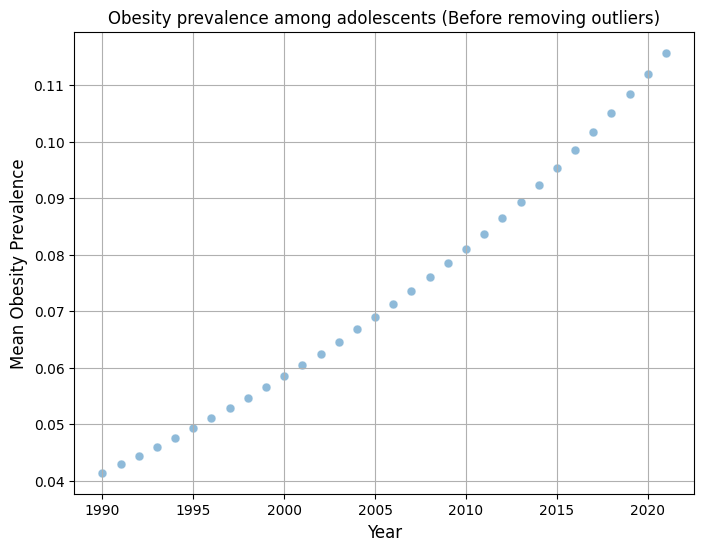

Pearsons Correlation: 0.9924


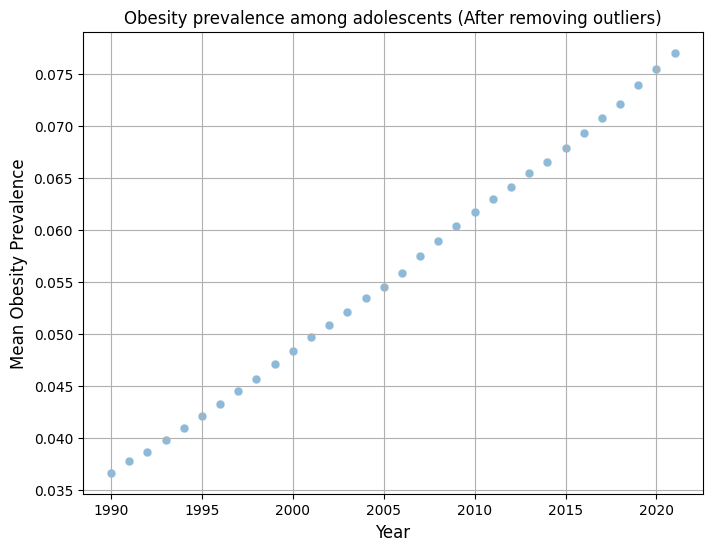

Pearsons Correlation: 0.9993


In [13]:
# before removing outliers
before_df_filtered = with_outliers_df[(with_outliers_df['location_level'] == 'Country')] # filter country
get_mean0 = before_df_filtered.groupby('year_id')['mean_prev'].mean().reset_index() # get the mean of mean_prev per year
pearson=get_mean0['year_id'].corr(get_mean0['mean_prev'], method='pearson')

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=get_mean0,
    x='year_id',
    y='mean_prev',
    s=40,
    alpha=0.5
)
plt.title("Obesity prevalence among adolescents (Before removing outliers)")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Obesity Prevalence", fontsize=12)
plt.grid(True)
plt.show()
print(f'Pearsons Correlation: {pearson:.4f}')

# after removing outliers
df_filtered = df[(df['location_level'] == 'Country')] # filter country
get_mean=df_filtered.groupby('year_id')['mean_prev'].mean().reset_index() # get the mean of mean_prev per year
pearson=get_mean['year_id'].corr(get_mean['mean_prev'], method='pearson')

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=get_mean,
    x='year_id',
    y='mean_prev',
    s=40,
    alpha=0.5
)
plt.title("Obesity prevalence among adolescents (After removing outliers)")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Obesity Prevalence", fontsize=12)
plt.grid(True)
plt.show()
print(f'Pearsons Correlation: {pearson:.4f}')

With a value of 0.9994, this suggests a strong positive correlation between year and obesity prevalence, indicating that as the years progress, obesity rates also increase. However, this does not imply that the progression of years causes increased obesity prevalence. There are other factors that we need to consider such as lifestyle, nutrition, and socioeconomic status.



The comparison between the two graphs shows that removing outliers had little to no effect on the overall evolution of global obesity prevalence from 1990 to 2021. Both graphs demonstrate a steady increase over time, suggesting that the rising trend is consistent within the dataset. Although removing outliers reduces fluctuations and improves the clarity of the trend, the original outliers may contain meaningful information about regions experiencing higher obesity rates. Since the objective is to understand global obesity patterns, retaining valid outliers provides a more complete representation of the differences between populations. The similarity in the peak growth period between both graphs indicates that the fastest increase in obesity prevalence is a genuine trend rather than an effect caused only by extreme values. 

**How do obesity prevalence trends and growth rates differ between younger children/adolescents (age 5-14) and young adults (age 15-24), and how does this pattern vary by sex?**

We will use bar graph to present the relationship between age, sex, and obesity rate.

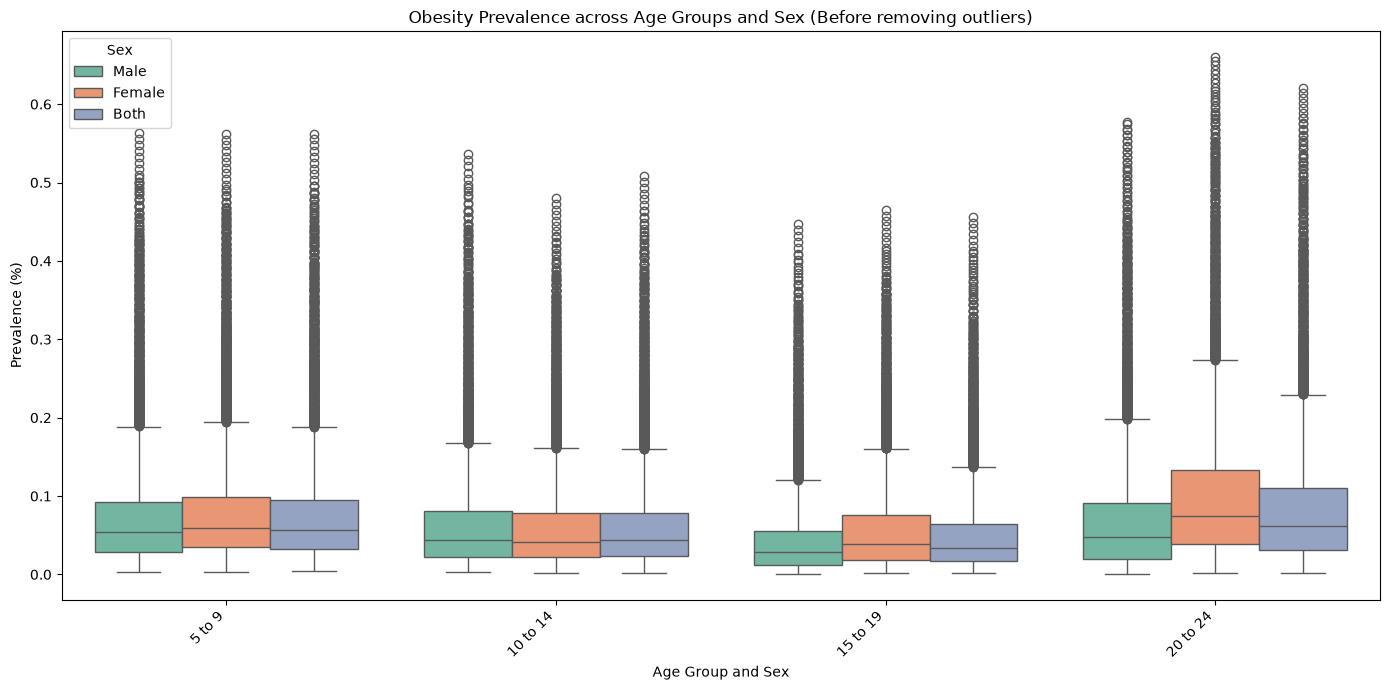

In [30]:
# before removing outliers
plt.figure(figsize=(14,7))

sns.boxplot(
    data = with_outliers_df,
    x = 'age_group_name',
    y = 'mean_prev',
    hue = 'Sex',
    palette =  'Set2'
)

plt.xlabel('Age Group and Sex')
plt.ylabel('Prevalence (%)')
plt.title('Obesity Prevalence across Age Groups and Sex (Before removing outliers)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


explain

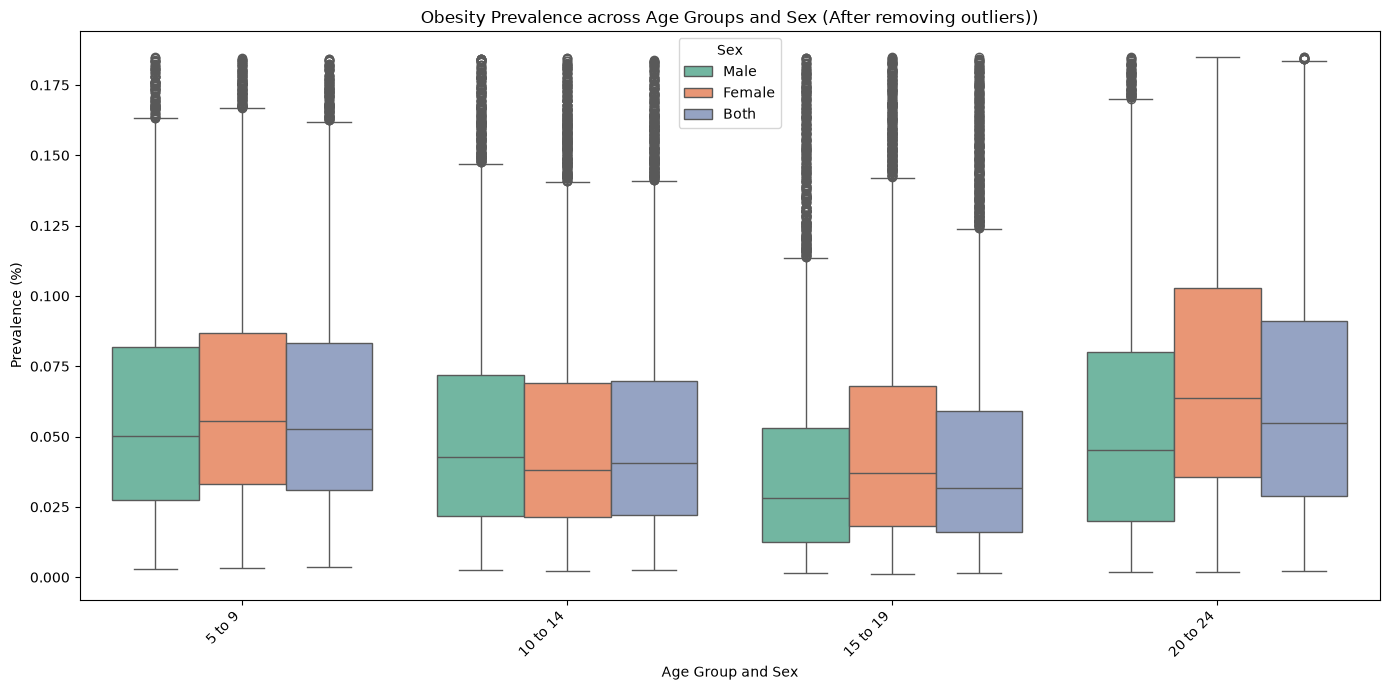

In [31]:
#after removing outliers
plt.figure(figsize=(14,7))

sns.boxplot(
    data = df,
    x = 'age_group_name',
    y = 'mean_prev',
    hue = 'Sex',
    palette =  'Set2'
)

plt.xlabel('Age Group and Sex')
plt.ylabel('Prevalence (%)')
plt.title('Obesity Prevalence across Age Groups and Sex (After removing outliers))')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Among all genders, the lowest obesity rate is observed in adolescents aged 15 to 19, while the highest is observed in those aged 20 to 24 with the rates very close to those in children aged 5 to 9. Within each age group analyzed, males had a higher obesity in the ages 10 to 14, otherwise the females had a significantly higher average obesity rate than males.

***// Add explanation for before and after***

**Which geographic regions exhibit the highest baseline prevalence, and which regions experienced the fastest rate of change over the study period?**

We will use bar graph to compare the mean obesity prevalence across different countries.

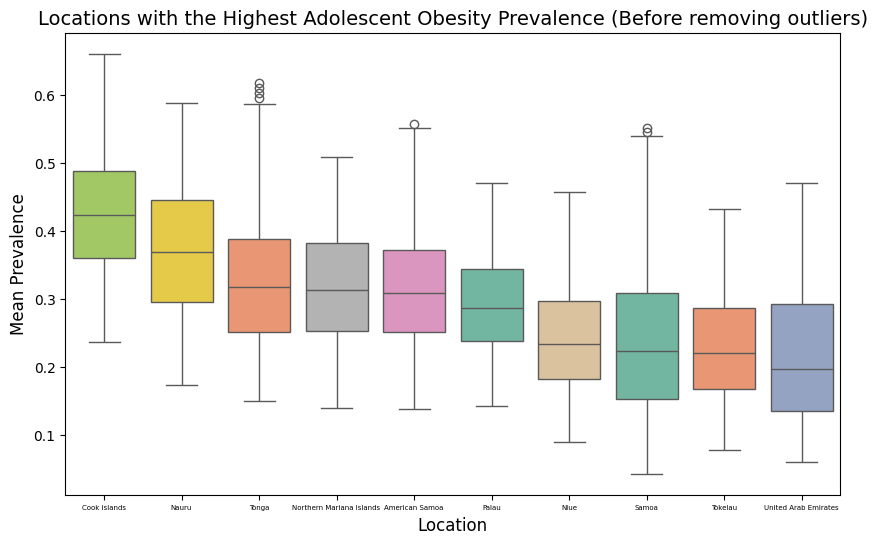

                        location_name      Mean    Median       Std
41                       Cook Islands  0.425868  0.422694  0.090816
123                             Nauru  0.373387  0.368612  0.097111
183                             Tonga  0.326201  0.317620  0.097550
132          Northern Mariana Islands  0.316756  0.312881  0.088159
3                      American Samoa  0.314250  0.308268  0.086868
..                                ...       ...       ...       ...
105                        Madagascar  0.010456  0.007482  0.008104
97   Lao People's Democratic Republic  0.010051  0.008975  0.005828
31                           Cambodia  0.008125  0.006290  0.005323
29                            Burundi  0.008011  0.006874  0.004964
200                          Viet Nam  0.005918  0.005269  0.002868

[204 rows x 4 columns]


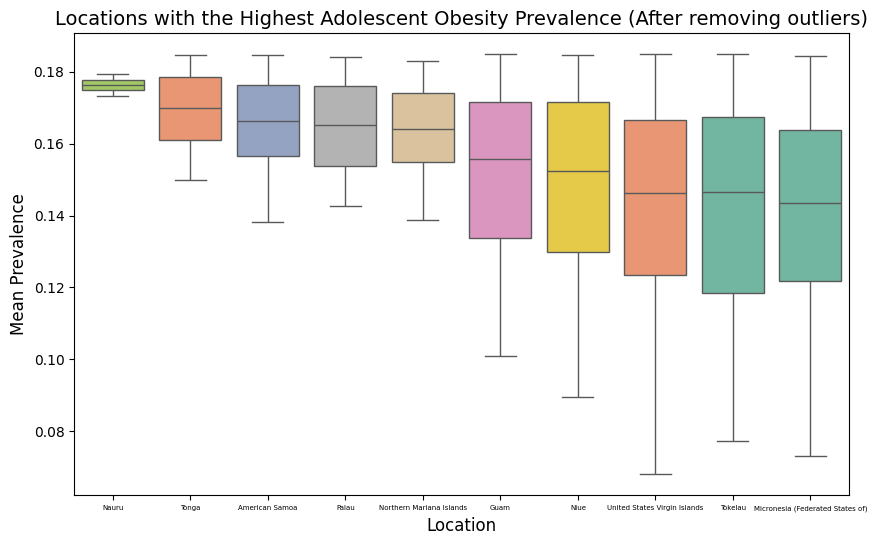

                        location_name      Mean    Median       Std
122                             Nauru  0.176332  0.176332  0.004213
180                             Tonga  0.169322  0.169860  0.010503
3                      American Samoa  0.164953  0.166326  0.013930
135                             Palau  0.164335  0.165295  0.013006
131          Northern Mariana Islands  0.163713  0.164022  0.012793
..                                ...       ...       ...       ...
104                        Madagascar  0.010456  0.007482  0.008104
96   Lao People's Democratic Republic  0.010051  0.008975  0.005828
31                           Cambodia  0.008125  0.006290  0.005323
29                            Burundi  0.008011  0.006874  0.004964
197                          Viet Nam  0.005918  0.005269  0.002868

[201 rows x 4 columns]


In [14]:
# before removing outliers
top_10 = (
    with_outliers_df[with_outliers_df['location_level'].str.lower() == 'country']
    .groupby('location_name')['mean_prev']
    .mean()
    .nlargest(10)
    .index
)

df_top_countries = with_outliers_df[with_outliers_df['location_name'].isin(top_10)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top_countries,
    x='location_name',
    y='mean_prev',
    hue = 'location_name',
    palette = 'Set2',
    order=top_10
)

plt.title("Locations with the Highest Adolescent Obesity Prevalence (Before removing outliers)", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Mean Prevalence", fontsize=12)
plt.xticks(fontsize=5)
plt.show()
country_stats=(before_df_filtered.groupby('location_name')['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index().sort_values(by='Mean', ascending=False))

print(country_stats)

# after removing outliers
top_10 = (
    df[df['location_level'].str.lower() == 'country']
    .groupby('location_name')['mean_prev']
    .mean()
    .nlargest(10)
    .index
)

df_top_countries = df[df['location_name'].isin(top_10)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top_countries,
    x='location_name',
    y='mean_prev',
    hue = 'location_name',
    palette = 'Set2',
    order=top_10
)

plt.title("Locations with the Highest Adolescent Obesity Prevalence (After removing outliers)", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Mean Prevalence", fontsize=12)
plt.xticks(fontsize=5)
plt.show()
country_stats=(df_filtered.groupby('location_name')['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index().sort_values(by='Mean', ascending=False))

print(country_stats)

Obesity prevalence varies significantly across different geographic locations. The graph shows that Cook Islands leads the ranking in obesity prevalence, followed closely by Pacific Island Nations such as Nauru, Niue, and Tonga.

***// Add explanation for before and after***

### How do demographic and geographic factors influence obesity prevalence among individuals aged 5–24 from the year 1990-2050? -- revise this


The first EDA connects to the research since this EDA is used to analyze and track the overall trend of obesity rates in people aged 5-24, which will help to analyze whether obesity rates are continuing to rise or fall, or stabilizing.

The second EDA question analyzes the relationship between age, sex, and obesity rate, which will help analyze whether demographic factors influence obesity rates. By breaking down the data into more specific age groups and sexes, the problem can identify which specific subgroups are bearing the heaviest burden or experiencing the fastest growth.



The third EDA question analyzes whether regional factors influence obesity rates. Obesity is significantly influenced by local drivers such as regional diet, national healthcare policies, socioeconomic development, and urbanization. Through data analysis, we can identify high-risk areas and provide necessary background information for analyzing whether population trends are similar globally or whether there are significant differences across different regions.


# Data Mining


### Initial brainstorming / thought process on choosing a technique (To be removed later)

Why is Association Rule Mining not a good fit for this?
- Our dataset contains continuous numerical estimates and not transactional or categorical data.

Why is Collaborative filtering (Recommender Systems) not a good for this?
- this is a technique used to predict a user's preferences based on the past behavior and opinions of similar users. Our dataset does not contain anything about users, ratings, or preferences.

### Why Clustering?

#### Clustering answers questions like:
1. Which oountries have similar obesity prevalence?
2. Which age-sex groups show similar obesity trends?
3. Are there distinct patterns in obesity across locations?

#### Before starting:
-  apply preprocessing techniques to transform the data into an appropriate representation.

-  does this algorithm require the values to be scaled?
    yes, k means clustering require the values to be scaled.

https://www.workhabit.org/does-k-means-require-scaling/

K means clustering uses euclidean distance which is influenced by the scale of features.

We should apply scaling in order to eliminate the potential issue of values with larger ranges dominating those with smaller ones.

Without scaling, larger scale features dominate, causing the model to prioritize these features and result in skewed clusters.
With scaling, no feature overshadows the other, which allows for a more balanced and accurate representation of data.

However, scaling could also lead to oversimplified models and require additional preprocessing.

### Select features

We select`mean_prev` and `mean_change` as the features for clustering, as these variables represent obesity prevalence levels and changes in prevalence over time. 

In [ ]:
features = [
    "mean_prev",
    "mean_change",
]

# Select features
X = df[features]

Perform scaling to transform each numerical feature to the same scale.

Feature scaling was performed before applying K-Means because the algorithm relies on Euclidean distance to measure similarity between observations. Standardizing these variables prevent the clustering process to be more influenced by one feature over the other, allowing for a more balanced and accurate representation of the data.

In [43]:
# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# convert back to dataframe
scaled_df = pd.DataFrame(scaled_data, columns=features)

# Preview
scaled_df.describe()

,mean_prev,mean_change
count,7.900700e+04,7.900700e+04
mean,1.151157e-16,-1.841851e-16
std,1.000006e+00,1.000006e+00
min,-1.314229e+00,-1.810272e+00
25%,-7.864008e-01,-7.771691e-01
50%,-2.556841e-01,-1.237474e-01
75%,5.491473e-01,5.571358e-01
max,3.183622e+00,2.953840e+00


Because K-means clustering algorithm requires the number of clusters to be specificed beforehand, we determine the optimal number of clusters using the Elbow method.

In [18]:
inertia = []

# look for the point where the decrease in inertia starts to level off
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

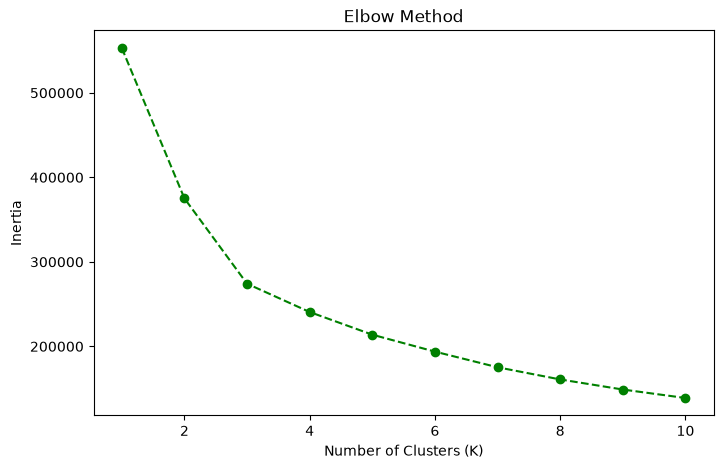

In [45]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o', linestyle='--', color='g') # X = # of clusters, Y = inertia
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

From this graph, the inertia starts to level off starting around K = 3 or K = 4.

To prove how distinct our clusters are without relying on visual guesswork, we compute the Silhouette score. The Silhouette score measures how similar each observation is to its assigned cluster compared to other clusters. A higher score indicates that the clusters are more clearly separated and that the observations are appropriately grouped.

we use the `fit_predict` function to train the K-Means clustering model on the scaled features and assign each observation to a cluster.

In [44]:
# compute the silhouette score to confirm the elbow result
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_df)
    
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)
    
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.353
K=3, Silhouette Score=0.402
K=4, Silhouette Score=0.362
K=5, Silhouette Score=0.354
K=6, Silhouette Score=0.371
K=7, Silhouette Score=0.376
K=8, Silhouette Score=0.351
K=9, Silhouette Score=0.343
K=10, Silhouette Score=0.344


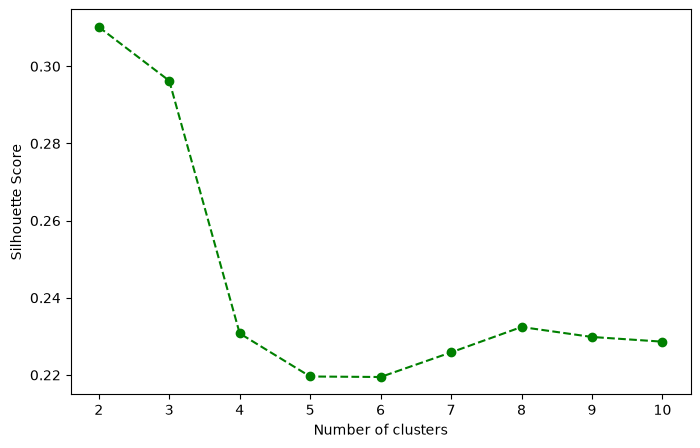

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o', linestyle='--', color='g')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

Since K=3 has the highest Silhouette Score of 0.296 and the plot shows that the inertia starts to level off starting at that point, we choose K=3 as the most optimal number of clusters.

In [33]:
# Create the KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model and assign clusters
clusters = kmeans.fit_predict(scaled_df)

# Store the cluster labels
df["Cluster"] = clusters

Analyze the clusters

In [36]:
df["Cluster"].value_counts()

Cluster
2    39738
0    19646
1    19623
Name: count, dtype: int64

In [37]:
df.groupby("Cluster")[features].mean()

,year_id,mean_prev,lower_prev,upper_prev,mean_change,lower_change,upper_change
Cluster,,,,,,,
0,2009.911280,0.112809,0.077950,0.155932,2.043366,0.727793,4.066419
1,2004.417164,0.032672,0.020983,0.048508,4.167954,1.671357,8.306692
2,2003.114299,0.037236,0.023710,0.055560,1.923696,0.498457,4.245073


# Statistical Inference

# Summary, Conclusions, and Recommendations

# References & Disclosures

Obesity: Health consequences of being overweight. (n.d.). https://www.who.int/news-room/questions-and-answers/item/obesity-health-consequences-of-being-overweight

https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(25)00397-6/fulltext

https://ghdx.healthdata.org/record/ihme-data/gbd-2021-child-adolescent-obesity-overweight-prevalence-1990-2050

